# HVAC  Electricity Demand analysis and prediction PMDARIMA

In [48]:
import pandas as pd
import datetime as dt
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, shapiro
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from pmdarima.arima import auto_arima
import multiprocessing


In [49]:
df = pd.read_csv("./data/Load_data_01.csv")
df["Time"] = pd.to_datetime(df["Time"])
df.set_index("Time", inplace=True)


In [50]:
def train_model(train_data):
    model = auto_arima(
        train_data,
        seasonal=True,
        trace=True,
        m=24,
        error_action="ignore",
        suppress_warnings=True,
        n_jobs=1,
    )
    return model

def train_and_evaluate_sarima(df, start_date, window_size):
    rmse_list = []
    r2_list = []

    for i in range(len(df) - window_size):
        train_start = start_date + pd.DateOffset(days=i)
        train_end = train_start + pd.DateOffset(days=window_size - 1)

        train_data = df.query(f"'{train_start}' <= Time <= '{train_end}'")[
            "electricity_demand_values"
        ]


        model = train_model(train_data)


        prediction_start = train_end + pd.DateOffset(days=1)
        prediction_end = prediction_start + pd.DateOffset(days=1, hours=-1)
        prediction_date_range = pd.date_range(
            prediction_start, prediction_end, freq="H"
        )
        forecast = model.predict(n_periods=len(prediction_date_range))


        test_data = df["electricity_demand_values"].loc[prediction_date_range]
        rmse = np.sqrt(mean_squared_error(test_data, forecast))
        r2 = r2_score(test_data, forecast)

        rmse_list.append(rmse)
        r2_list.append(r2)

        print(f"Prediction Window: {prediction_start} to {prediction_end}")
        print(f"RMSE: {rmse}")
        print(f"R2 Score: {r2}")

    return rmse_list, r2_list


In [51]:
# 定义并行处理的进程数
num_processes = 12

start_date = pd.to_datetime("2018-08-01")
window_size = 6  # n天的窗口


In [ ]:
# 调用函数
rmse_list, r2_list = train_and_evaluate_sarima(df, start_date, window_size)


In [ ]:
# 输出所有RMSE和R2分数
print("All RMSE:", rmse_list)
print("All R2 Score:", r2_list)


In [23]:
def train_and_evaluate_sarima(df, start_date, window_size):
    rmse_list = []
    r2_list = []

    for i in range(len(df) - window_size):
        train_start = start_date + pd.DateOffset(days=i)
        train_end = train_start + pd.DateOffset(days=window_size - 1)

        # 训练数据时间窗口
        train_data = df.query(f"'{train_start}' <= Time <= '{train_end}'")[
            "electricity_demand_values"
        ]

        # 训练SARIMA模型
        model = auto_arima(
            train_data,
            seasonal=True,
            trace=True,
            m=24,
            error_action="ignore",
            suppress_warnings=True,
            n_jobs=4
        )

        # 预测下一天的用电量数据
        prediction_start = train_end + pd.DateOffset(days=1)
        prediction_end = prediction_start + pd.DateOffset(days=1, hours=-1)
        prediction_date_range = pd.date_range(
            prediction_start, prediction_end, freq="H"
        )
        forecast = model.predict(n_periods=len(prediction_date_range))

        # 计算RMSE和R2分数
        test_data = df["electricity_demand_values"].loc[prediction_date_range]
        rmse = np.sqrt(mean_squared_error(test_data, forecast))
        r2 = r2_score(test_data, forecast)

        # 记录RMSE和R2到列表中
        rmse_list.append(rmse)
        r2_list.append(r2)

        print(f"Prediction Window: {prediction_start} to {prediction_end}")
        print(f"RMSE: {rmse}")
        print(f"R2 Score: {r2}")

    return rmse_list, r2_list


In [24]:
start_date = pd.to_datetime("2018-08-01")
window_size = 7  


In [25]:
rmse_list, r2_list = train_and_evaluate_sarima(df, start_date, window_size)


/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=1538.258, Time=0.58 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=2119.215, Time=0.00 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=2280.260, Time=0.00 sec
 ARIMA(2,0,2)(0,0,1)[24] intercept   : AIC=1553.784, Time=0.38 sec
 ARIMA(2,0,2)(1,0,0)[24] intercept   : AIC=1541.836, Time=0.49 sec
 ARIMA(2,0,2)(2,0,1)[24] intercept   : AIC=inf, Time=3.90 sec
 ARIMA(2,0,2)(1,0,2)[24] intercept   : AIC=1540.715, Time=4.05 sec
 ARIMA(2,0,2)(0,0,0)[24] intercept   : AIC=1583.173, Time=0.11 sec
 ARIMA(2,0,2)(0,0,2)[24] intercept   : AIC=1548.200, Time=4.45 sec
 ARIMA(2,0,2)(2,0,0)[24] intercept   : AIC=1545.862, Time=5.08 sec
 ARIMA(2,0,2)(2,0,2)[24] intercept   : AIC=inf, Time=4.05 sec
 ARIMA(1,0,2)(1,0,1)[24] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(2,0,1)(1,0,1)[24] intercept   : AIC=1

/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=1509.965, Time=0.62 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=2077.539, Time=0.00 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=1854.272, Time=0.32 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=2249.413, Time=0.00 sec
 ARIMA(2,0,2)(0,0,1)[24] intercept   : AIC=1551.426, Time=0.46 sec
 ARIMA(2,0,2)(1,0,0)[24] intercept   : AIC=1523.034, Time=0.52 sec
 ARIMA(2,0,2)(2,0,1)[24] intercept   : AIC=inf, Time=4.33 sec
 ARIMA(2,0,2)(1,0,2)[24] intercept   : AIC=1538.653, Time=5.77 sec
 ARIMA(2,0,2)(0,0,0)[24] intercept   : AIC=1578.352, Time=0.09 sec
 ARIMA(2,0,2)(0,0,2)[24] intercept   : AIC=1535.115, Time=10.91 sec
 ARIMA(2,0,2)(2,0,0)[24] intercept   : AIC=1516.304, Time=3.50 sec
 ARIMA(2,0,2)(2,0,2)[24] intercept   : AIC=inf, Time=4.33 sec
 ARIMA(1,0,2)(1,0,1)[24] intercept   : AIC=1512.304, Time=0.60 sec
 ARIMA(2,0,1)(1,0,1)[24] intercept   : AIC=1511.948, Time=0.53 sec
 ARIMA(3,

/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=1511.146, Time=0.61 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=2057.533, Time=0.00 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=1822.832, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=2239.897, Time=0.00 sec
 ARIMA(2,0,2)(0,0,1)[24] intercept   : AIC=1536.824, Time=0.42 sec
 ARIMA(2,0,2)(1,0,0)[24] intercept   : AIC=1533.440, Time=0.66 sec
 ARIMA(2,0,2)(2,0,1)[24] intercept   : AIC=inf, Time=4.10 sec
 ARIMA(2,0,2)(1,0,2)[24] intercept   : AIC=1508.705, Time=3.85 sec
 ARIMA(2,0,2)(0,0,2)[24] intercept   : AIC=1513.228, Time=3.47 sec
 ARIMA(2,0,2)(2,0,2)[24] intercept   : AIC=inf, Time=4.83 sec
 ARIMA(1,0,2)(1,0,2)[24] intercept   : AIC=1493.419, Time=3.70 sec
 ARIMA(1,0,2)(0,0,2)[24] intercept   : AIC=inf, Time=3.01 sec
 ARIMA(1,0,2)(1,0,1)[24] intercept   : AIC=inf, Time=0.55 sec
 ARIMA(1,0,2)(2,0,2)[24] intercept   : AIC=1494.553, Time=4.01 sec
 ARIMA(1,0,2)(0,0,1)

KeyboardInterrupt: 

In [ ]:
# 输出所有RMSE和R2分数
print("All RMSE:", rmse_list)
print("All R2 Score:", r2_list)


In [ ]:
# demand_train = df.query("'2018-09-15 ' <= Time < '2018-09-19'")[
#     "electricity_demand_values"
# ]


In [ ]:
# model = pm.auto_arima(
#     demand_train,
#     seasonal=True,
#     trace=True,
#     m=24,
#     error_action="ignore",
#     suppress_warnings=True,
# )

# # model.summary(), model.plot_diagnostics(figsize=(10, 8))


In [ ]:
# test = df["electricity_demand_values"].loc[
#     "2018-09-20 00:00:00":"2018-09-20 23:00:00"
# ]

# forecast = model.predict(n_periods=len(test))
# rmse = np.sqrt(mean_squared_error(test, forecast))
# r2 = r2_score(test, forecast)
# # Print the results
# print(f"RMSE: {rmse}")
# print(f"R2 Score: {r2}")


In [70]:
window_sizes = [2,6, 12, 24]
for window_size in window_sizes:
    df[f"movave_{window_size}"] = df['electricity_demand_values'].rolling(window_size).mean()
    df[f"movstd_{window_size}"] = df['electricity_demand_values'].rolling(window_size).std()


In [73]:
mean = np.mean(df['electricity_demand_values'])
std = np.std(df['electricity_demand_values'])
skew = skew(df['electricity_demand_values'])
ex_kurtosis = kurtosis(df['electricity_demand_values'])


In [83]:
skew, ex_kurtosis


(1.8077700842663937, 3.8616797115860706)

In [84]:
def shapiro_test(df, alpha=0.05):
    stat, pval = shapiro(df)
    print("H0: df was drawn from a Normal Ditribution")
    if pval < alpha:
        print(
            "pval {} is lower than significance level: {}, therefore null hypothesis is rejected".format(
                pval, alpha
            )
        )
    else:
        print(
            "pval {} is higher than significance level: {}, therefore null hypothesis cannot be rejected".format(
                pval, alpha
            )
        )




In [85]:
shapiro_test(df['electricity_demand_values'],alpha=0.05)


H0: df was drawn from a Normal Ditribution
pval 0.0 is lower than significance level: 0.05, therefore null hypothesis is rejected


/Users/sagawithme/.conda/envs/p39/lib/python3.11/site-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_89276/415212071.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['electricity_demand_values'], bins=50, kde=True)


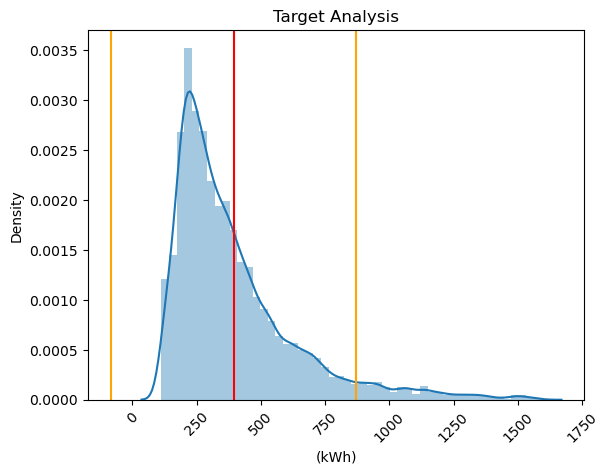

In [86]:
sns.distplot(df['electricity_demand_values'], bins=50, kde=True)
plt.title("Target Analysis")
plt.xticks(rotation=45)
plt.xlabel("(kWh)")
plt.axvline(x=mean, color="r", linestyle="-", label="\mu: {0:.2f}%".format(mean))
plt.axvline(x=mean + 2 * std, color="orange", linestyle="-")
plt.axvline(x=mean - 2 * std, color="orange", linestyle="-")
plt.show()


/var/folders/9h/gh5zy8tj3xl95bg3c5mbjmpc0000gn/T/ipykernel_89276/1036258791.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df["electricity_demand_values"]), bins=50, kde=True)


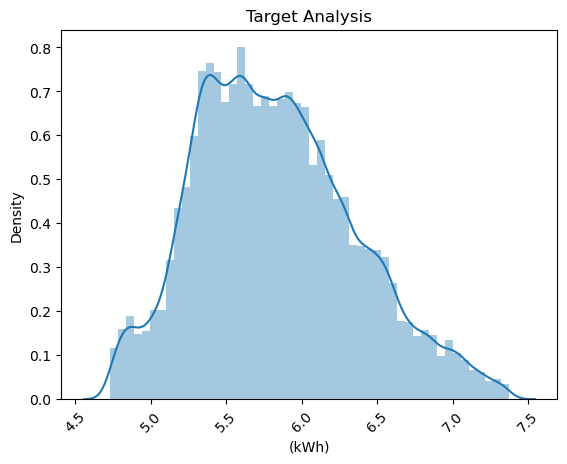

In [91]:
sns.distplot(np.log(df["electricity_demand_values"]), bins=50, kde=True)

plt.title("Target Analysis")
plt.xticks(rotation=45)
plt.xlabel("(kWh)")

# plt.axvline(x=mean, color="r", linestyle="-", label="\mu: {0:.2f}%".format(mean))

# plt.axvline(x=mean + 2 * std, color="orange", linestyle="-")
# plt.axvline(x=mean - 2 * std, color="orange", linestyle="-")
plt.show()


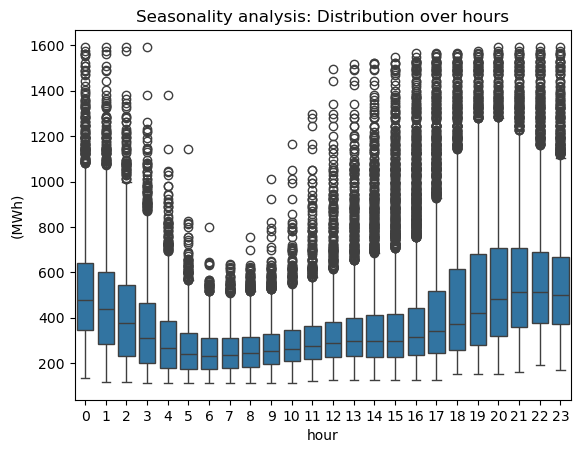

In [78]:
sns.boxplot(
    data=df, x="hour", y="electricity_demand_values"
)
plt.title("Seasonality analysis: Distribution over hours")
plt.ylabel("(MWh)")
plt.show()


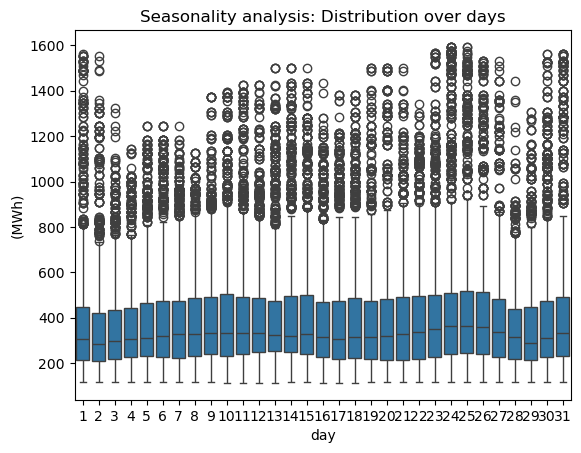

In [79]:
sns.boxplot(data=df, x="day", y="electricity_demand_values")
plt.title("Seasonality analysis: Distribution over days")
plt.ylabel("(MWh)")
plt.show()


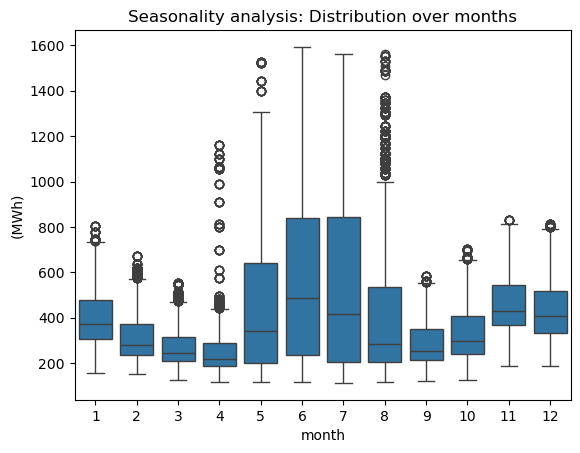

In [80]:
sns.boxplot(data=df, x="month", y="electricity_demand_values")
plt.title("Seasonality analysis: Distribution over months")
plt.ylabel("(MWh)")
plt.show()


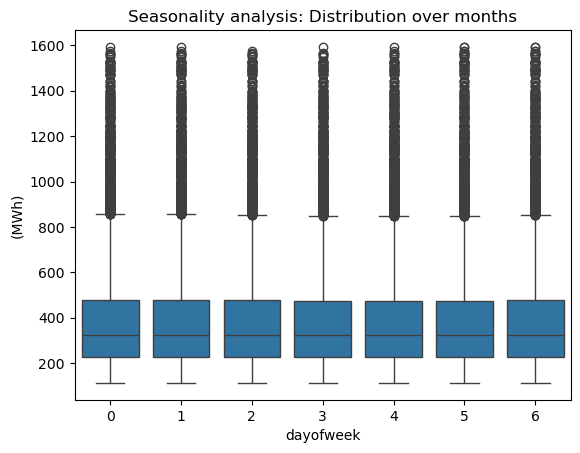

In [81]:
sns.boxplot(data=df, x="dayofweek", y="electricity_demand_values")
plt.title("Seasonality analysis: Distribution over months")
plt.ylabel("(MWh)")
plt.show()


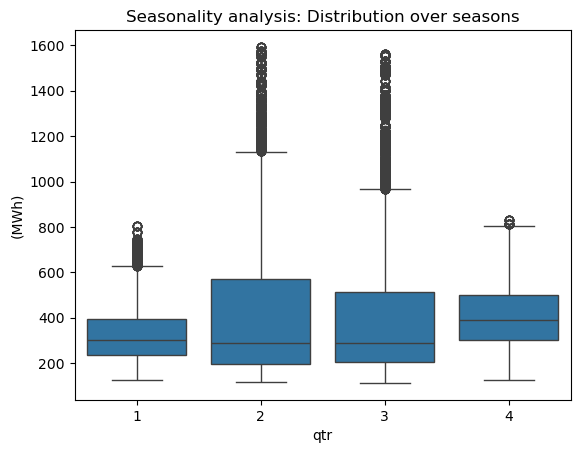

In [82]:
sns.boxplot(data=df, x="qtr", y="electricity_demand_values")
plt.title("Seasonality analysis: Distribution over seasons")
plt.ylabel("(MWh)")
plt.show()
